# Clasificacion en Machine Learning: diagnostico de diabetes

Este notebook desarrolla, paso a paso, un problema de **clasificacion binaria** usando Python y scikit-learn. El objetivo es construir modelos que permitan estimar si una paciente presenta signos compatibles con diabetes a partir de variables clinicas.

El enfoque sera pedagogico: antes de cada bloque de codigo se explica que se hara, por que se hace y como interpretar los resultados.

## 1. Introduccion al problema

En este caso queremos predecir la variable **Outcome**, que toma dos valores:

- `0`: la paciente no presenta diabetes segun el registro del dataset.
- `1`: la paciente presenta diabetes segun el registro del dataset.

Es un problema de **clasificacion** porque la variable objetivo no es numerica continua, sino una categoria. En particular, es una clasificacion binaria porque solo existen dos clases posibles.

Las variables predictoras son mediciones clinicas como glucosa, presion arterial, indice de masa corporal, edad, insulina y otras variables relacionadas con antecedentes o caracteristicas medicas.

Usaremos el dataset **Pima Indians Diabetes**, disponible publicamente en un repositorio de datasets de Plotly: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv. Este dataset se usa con frecuencia para practicas de clasificacion medica. Aunque es util para aprendizaje, no debe entenderse como una herramienta clinica real sin validacion medica, auditoria y pruebas adicionales.

## 2. Carga de librerias

Primero verificamos que las dependencias necesarias esten instaladas. Si alguna falta, la siguiente celda la instala con `pip`. Esto ayuda a que el notebook pueda ejecutarse desde cero en un entorno nuevo.

Luego importamos las librerias necesarias. Usaremos:

- `pandas` y `numpy` para manipulacion de datos.
- `matplotlib` y `seaborn` para visualizacion.
- `scikit-learn` para preparar datos, entrenar modelos y evaluarlos.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Instalando dependencias faltantes:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Todas las dependencias necesarias estan instaladas.")

Todas las dependencias necesarias estan instaladas.


Importamos las librerias necesarias. Usaremos:

- `pandas` y `numpy` para manipulacion de datos.
- `matplotlib` y `seaborn` para visualizacion.
- `scikit-learn` para preparar datos, entrenar modelos y evaluarlos.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 3. Carga del dataset

Cargamos el archivo CSV directamente desde internet. Esto permite que el notebook pueda ejecutarse desde cero sin depender de archivos locales.

Despues de cargar los datos, mostramos las primeras filas para reconocer la estructura general de la tabla.

In [3]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


La tabla contiene una fila por paciente y varias columnas numericas. La columna `Outcome` sera la variable objetivo. Todas las demas columnas seran candidatas a variables predictoras.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4. Analisis exploratorio de datos

El analisis exploratorio permite entender el tamano del dataset, los tipos de variables, posibles valores faltantes, distribuciones y relaciones iniciales. Antes de entrenar un modelo, este paso ayuda a detectar problemas de calidad de datos y a tomar decisiones tecnicas razonables.

In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.dtypes

Filas: 768
Columnas: 9


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Revisamos valores nulos explicitos. Un valor nulo explicito es un `NaN` reconocido directamente por pandas. Sin embargo, en datasets medicos tambien es frecuente encontrar codigos como `0` para representar una medicion no registrada.

In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Calculamos estadisticas descriptivas. Esto nos permite detectar rangos, medias, dispersion y valores sospechosos. En variables como glucosa, presion arterial, grosor de piel, insulina o IMC, un valor de `0` no suele ser clinicamente interpretable como medicion real.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Observamos la distribucion de la variable objetivo. Esto es importante porque un dataset desbalanceado puede hacer que la exactitud sea enganosa. Por ejemplo, si la mayoria de pacientes fueran clase `0`, un modelo podria obtener alta accuracy prediciendo casi siempre `0`, pero seria poco util para detectar casos positivos.

,conteo,porcentaje
Outcome,,
0,500,65.1
1,268,34.9


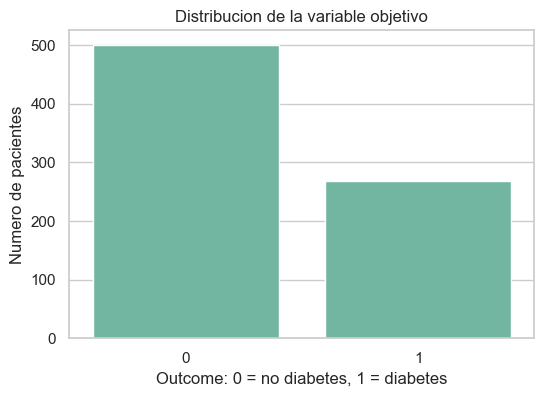

In [8]:
target_counts = df["Outcome"].value_counts().sort_index()
target_percent = df["Outcome"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({"conteo": target_counts, "porcentaje": target_percent.round(2)}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Outcome: 0 = no diabetes, 1 = diabetes")
plt.ylabel("Numero de pacientes")
plt.show()

Graficamos histogramas de las variables predictoras. Los histogramas permiten ver concentraciones, asimetrias, posibles valores extremos y acumulaciones anormales en cero.

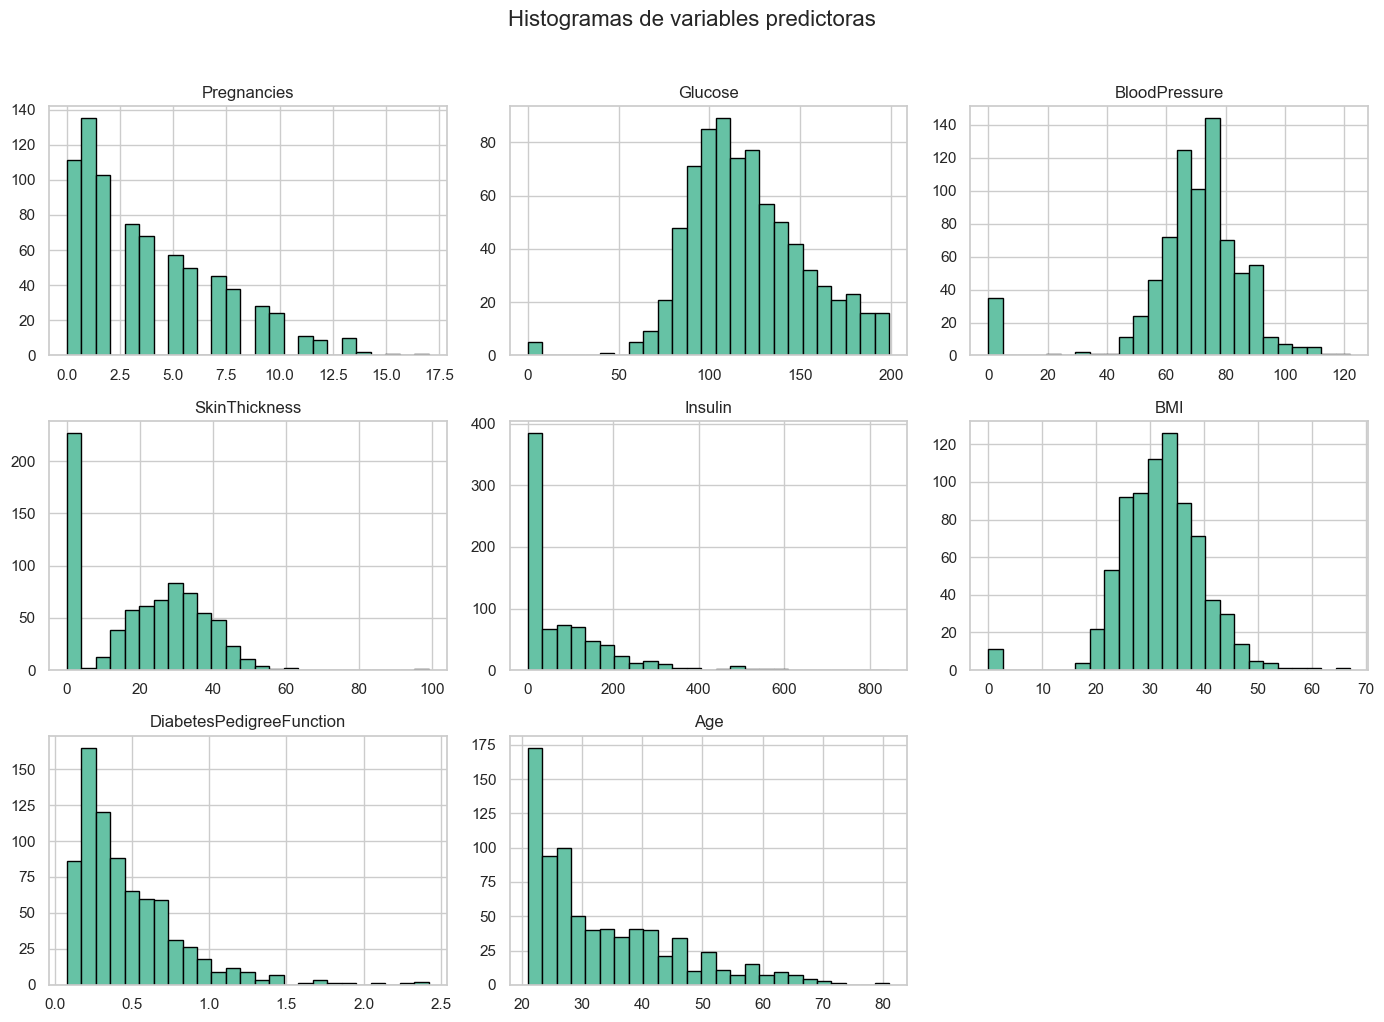

In [9]:
feature_columns = [col for col in df.columns if col != "Outcome"]

df[feature_columns].hist(figsize=(14, 10), bins=25, edgecolor="black")
plt.suptitle("Histogramas de variables predictoras", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

Tambien comparamos algunas variables con la variable objetivo. En este caso, usamos boxplots para observar si las distribuciones de glucosa, IMC y edad cambian entre pacientes sin diabetes y con diabetes.

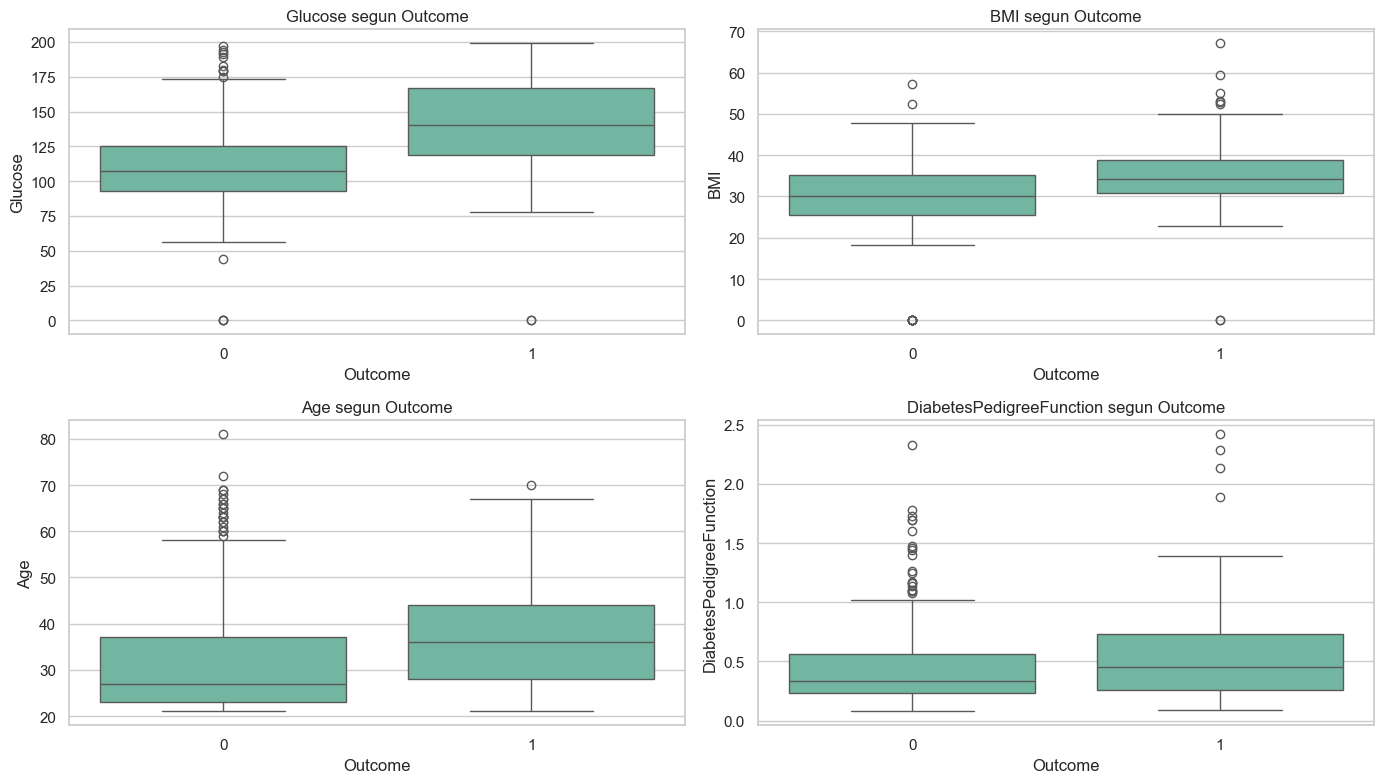

In [10]:
selected_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(selected_features, start=1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="Outcome", y=col)
    plt.title(f"{col} segun Outcome")
    plt.xlabel("Outcome")
plt.tight_layout()
plt.show()

La matriz de correlacion ayuda a identificar relaciones lineales entre variables. No implica causalidad, pero puede orientar la interpretacion. En clasificacion medica, variables como glucosa e IMC suelen tener relacion con el riesgo de diabetes.

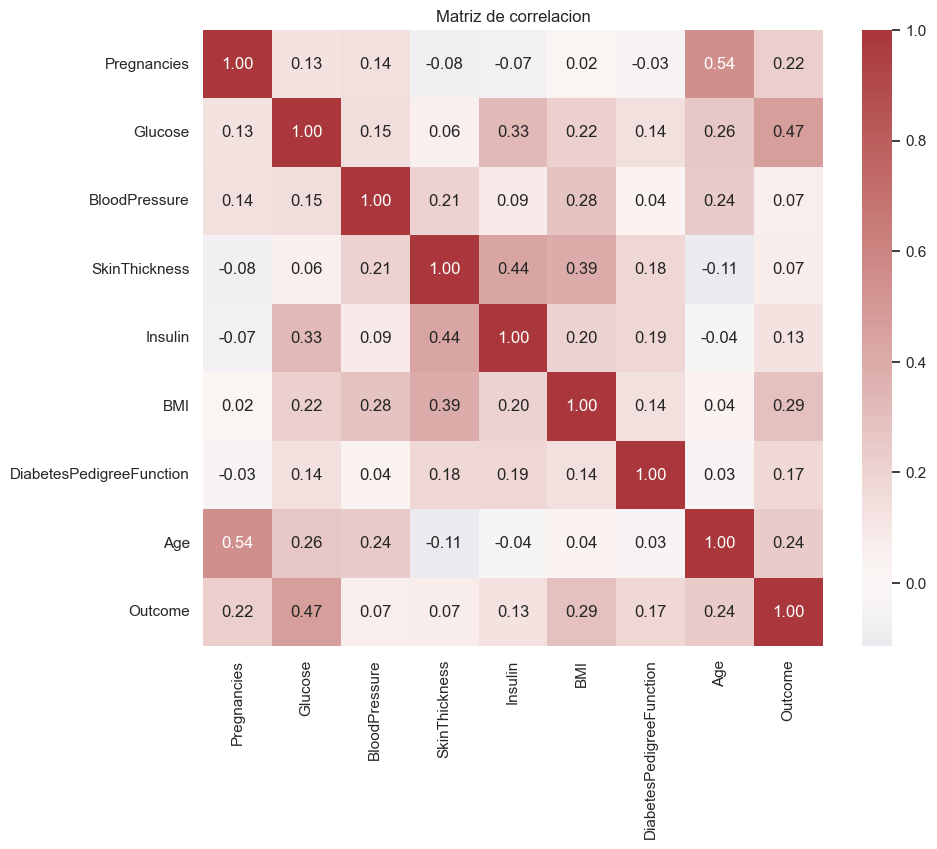

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

## 5. Preparacion de datos

Antes del modelado corregimos valores problematicos. Aunque pandas no detecto valores nulos explicitos, varias variables tienen ceros que no son plausibles como mediciones reales:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Convertiremos esos ceros en `NaN` para que luego puedan ser imputados dentro del pipeline. Es importante hacer la imputacion dentro del pipeline para evitar fuga de informacion: la mediana debe aprenderse solo con los datos de entrenamiento.

In [12]:
df_clean = df.copy()

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

df_clean[zero_as_missing].isna().sum().sort_values(ascending=False)

Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64

Separamos variables predictoras (`X`) y variable objetivo (`y`). Esta separacion es fundamental porque el modelo debe aprender a predecir `y` usando solamente la informacion de `X`.

In [13]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


Dividimos el dataset en entrenamiento y prueba. El conjunto de entrenamiento se usa para ajustar los modelos; el conjunto de prueba se reserva para evaluar desempeno en datos no vistos.

Usamos `stratify=y` para mantener una proporcion similar de clases en ambos conjuntos.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Tamanos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Tamanos:
X_train: (576, 8)
X_test:  (192, 8)
y_train: (576,)
y_test:  (192,)


Definimos transformaciones de preprocesamiento. Como todas las variables son numericas, imputaremos los valores faltantes con la mediana. Para regresion logistica tambien escalaremos variables, porque este modelo es sensible a la escala de los predictores.

El arbol de decision no necesita escalado, porque toma decisiones mediante cortes del tipo `variable <= valor`.

In [15]:
numeric_features = X.columns.tolist()

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features)
    ]
)

## 6. Modelado

Entrenaremos dos modelos de clasificacion:

### Regresion logistica

La regresion logistica estima la probabilidad de pertenecer a la clase positiva. Aunque su nombre incluye la palabra regresion, se usa ampliamente en clasificacion binaria.

Hiperparametros configurados:

- `max_iter=1000`: aumenta el numero maximo de iteraciones para asegurar convergencia.
- `class_weight='balanced'`: da mas peso a la clase menos frecuente, util cuando queremos no ignorar casos positivos.
- `random_state=42`: hace reproducible el resultado.

### Arbol de decision

Un arbol de decision divide los datos mediante reglas simples, por ejemplo `Glucose <= 127.5`. Es interpretable y puede capturar relaciones no lineales.

Hiperparametros configurados:

- `max_depth=4`: limita la profundidad para reducir sobreajuste.
- `min_samples_leaf=15`: exige un minimo de observaciones en cada hoja, haciendo el arbol mas estable.
- `class_weight='balanced'`: compensa parcialmente el desbalance de clases.
- `random_state=42`: hace reproducible el entrenamiento.

In [16]:
logistic_model = Pipeline(steps=[
    ("preprocess", logistic_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

tree_model = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

## 7. Entrenamiento

Entrenar significa ajustar los parametros internos del modelo usando los datos de entrenamiento. En una regresion logistica se aprenden coeficientes; en un arbol se aprenden reglas de particion.

In [17]:
logistic_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


## 8. Evaluacion de modelos

Evaluaremos cada modelo con varias metricas:

- **Accuracy**: proporcion total de predicciones correctas.
- **Precision**: de los casos predichos como diabetes, cuantos realmente eran diabetes.
- **Recall** o sensibilidad: de los casos reales de diabetes, cuantos detecto el modelo.
- **F1-score**: promedio armonico entre precision y recall.
- **Matriz de confusion**: muestra verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
- **ROC-AUC**: mide la capacidad de separar clases considerando diferentes umbrales de decision.

En un problema medico, el recall de la clase positiva suele ser especialmente importante, porque un falso negativo podria significar no detectar una paciente en riesgo. Aun asi, tambien debemos vigilar precision para evitar demasiadas alertas falsas.

In [18]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))
    
    return metrics, y_pred, y_proba

logistic_metrics, logistic_pred, logistic_proba = evaluate_model(
    "Regresion logistica", logistic_model, X_test, y_test
)

tree_metrics, tree_pred, tree_proba = evaluate_model(
    "Arbol de decision", tree_model, X_test, y_test
)


===== Regresion logistica =====
              precision    recall  f1-score   support

 No diabetes       0.83      0.78      0.80       125
    Diabetes       0.63      0.70      0.66        67

    accuracy                           0.75       192
   macro avg       0.73      0.74      0.73       192
weighted avg       0.76      0.75      0.75       192


===== Arbol de decision =====
              precision    recall  f1-score   support

 No diabetes       0.85      0.70      0.77       125
    Diabetes       0.58      0.78      0.67        67

    accuracy                           0.73       192
   macro avg       0.72      0.74      0.72       192
weighted avg       0.76      0.73      0.74       192



Visualizamos las matrices de confusion. En este contexto:

- **Verdadero negativo**: paciente sin diabetes predicha como sin diabetes.
- **Falso positivo**: paciente sin diabetes predicha como con diabetes.
- **Falso negativo**: paciente con diabetes predicha como sin diabetes.
- **Verdadero positivo**: paciente con diabetes predicha como con diabetes.

Los falsos negativos son delicados porque representan casos positivos no detectados.

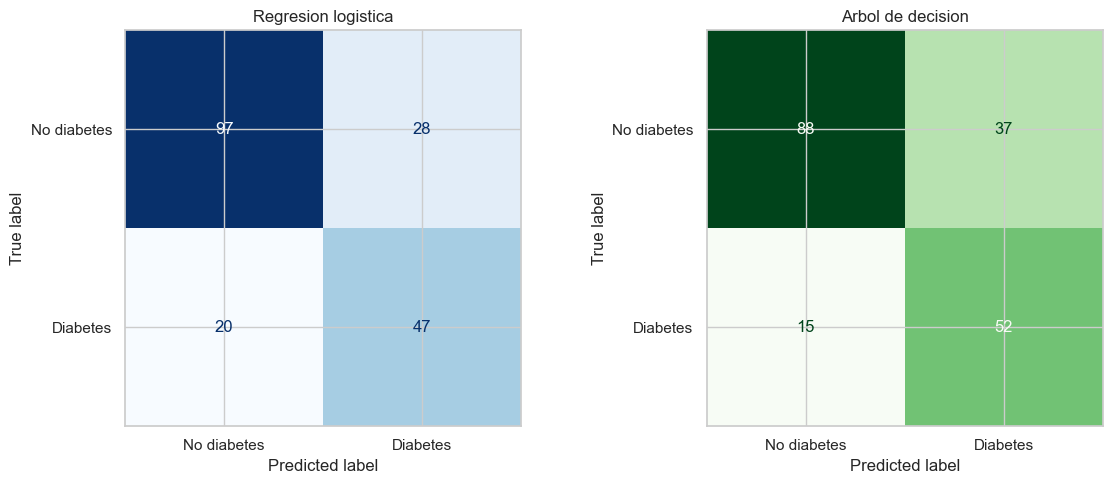

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Regresion logistica")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Greens",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Arbol de decision")

plt.tight_layout()
plt.show()

La curva ROC muestra la relacion entre la tasa de verdaderos positivos y la tasa de falsos positivos para diferentes umbrales. El AUC resume esa curva: valores cercanos a 1 indican mejor separacion entre clases; un valor cercano a 0.5 equivale aproximadamente a clasificar al azar.

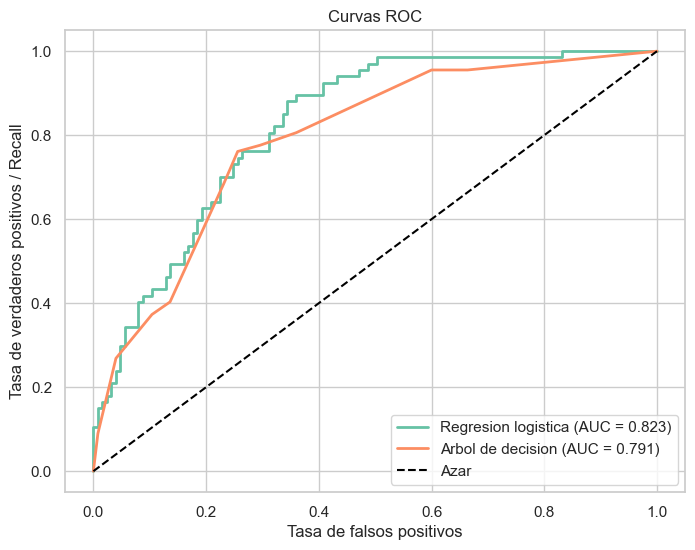

In [20]:
plt.figure(figsize=(8, 6))

for name, y_proba in [
    ("Regresion logistica", logistic_proba),
    ("Arbol de decision", tree_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {model_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Recall")
plt.title("Curvas ROC")
plt.legend()
plt.show()

## 9. Comparacion de modelos

Construimos una tabla comparativa con las metricas principales. Esto permite analizar el desempeno de forma ordenada. El mejor modelo no siempre es el que tiene mayor accuracy; en un problema medico puede interesar mas un buen equilibrio entre recall y precision, o priorizar recall si el costo de no detectar la condicion es alto.

In [21]:
results = pd.DataFrame([logistic_metrics, tree_metrics]).set_index("modelo")
results.round(3)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresion logistica,0.750,0.627,0.701,0.662,0.823
Arbol de decision,0.729,0.584,0.776,0.667,0.791


Visualizamos la comparacion para facilitar la lectura. Las barras permiten identificar rapidamente diferencias entre modelos en accuracy, precision, recall, F1 y ROC-AUC.

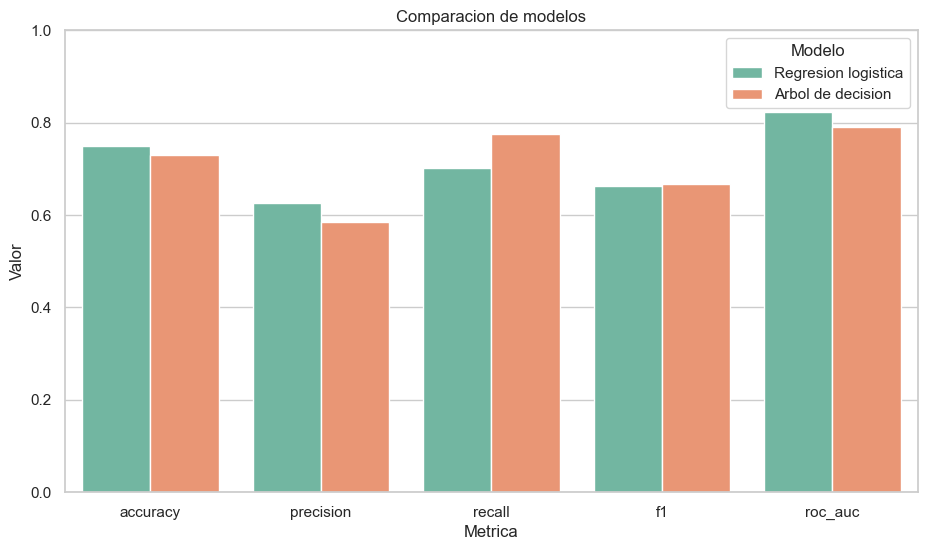

In [22]:
results_plot = results.reset_index().melt(id_vars="modelo", var_name="metrica", value_name="valor")

plt.figure(figsize=(11, 6))
sns.barplot(data=results_plot, x="metrica", y="valor", hue="modelo")
plt.ylim(0, 1)
plt.title("Comparacion de modelos")
plt.xlabel("Metrica")
plt.ylabel("Valor")
plt.legend(title="Modelo")
plt.show()

Seleccionamos automaticamente el modelo con mayor ROC-AUC y tambien revisamos el mejor F1-score. Esto no reemplaza el juicio del analista, pero ayuda a construir una conclusion tecnica basada en evidencia.

In [23]:
best_auc_model = results["roc_auc"].idxmax()
best_f1_model = results["f1"].idxmax()

print(f"Mejor modelo segun ROC-AUC: {best_auc_model} ({results.loc[best_auc_model, 'roc_auc']:.3f})")
print(f"Mejor modelo segun F1-score: {best_f1_model} ({results.loc[best_f1_model, 'f1']:.3f})")

if best_auc_model == best_f1_model:
    print(f"En esta ejecucion, {best_auc_model} ofrece el mejor desempeno global entre los dos criterios.")
else:
    print("Los criterios no eligen el mismo modelo; en un caso medico conviene revisar recall, precision y costos de error antes de decidir.")

Mejor modelo segun ROC-AUC: Regresion logistica (0.823)
Mejor modelo segun F1-score: Arbol de decision (0.667)
Los criterios no eligen el mismo modelo; en un caso medico conviene revisar recall, precision y costos de error antes de decidir.


Analizamos tambien la importancia o influencia de variables. En regresion logistica, despues del escalado, la magnitud de los coeficientes permite observar que variables empujan mas la probabilidad hacia la clase positiva o negativa. En el arbol, la importancia indica que variables fueron mas usadas para reducir impureza en las divisiones.

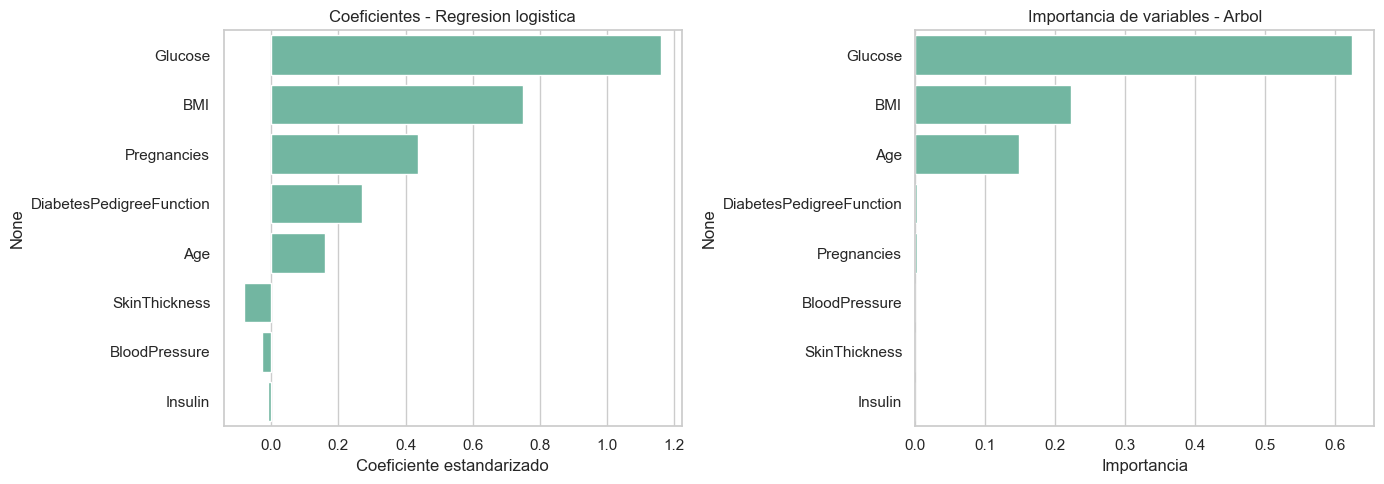

In [24]:
logistic_coefficients = pd.Series(
    logistic_model.named_steps["model"].coef_[0],
    index=numeric_features,
).sort_values(key=np.abs, ascending=False)

tree_importances = pd.Series(
    tree_model.named_steps["model"].feature_importances_,
    index=numeric_features,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=logistic_coefficients.values, y=logistic_coefficients.index, ax=axes[0])
axes[0].set_title("Coeficientes - Regresion logistica")
axes[0].set_xlabel("Coeficiente estandarizado")

sns.barplot(x=tree_importances.values, y=tree_importances.index, ax=axes[1])
axes[1].set_title("Importancia de variables - Arbol")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

Como el arbol de decision es interpretable, podemos visualizar sus reglas principales. Esta grafica ayuda a explicar como el modelo separa pacientes segun cortes en variables clinicas.

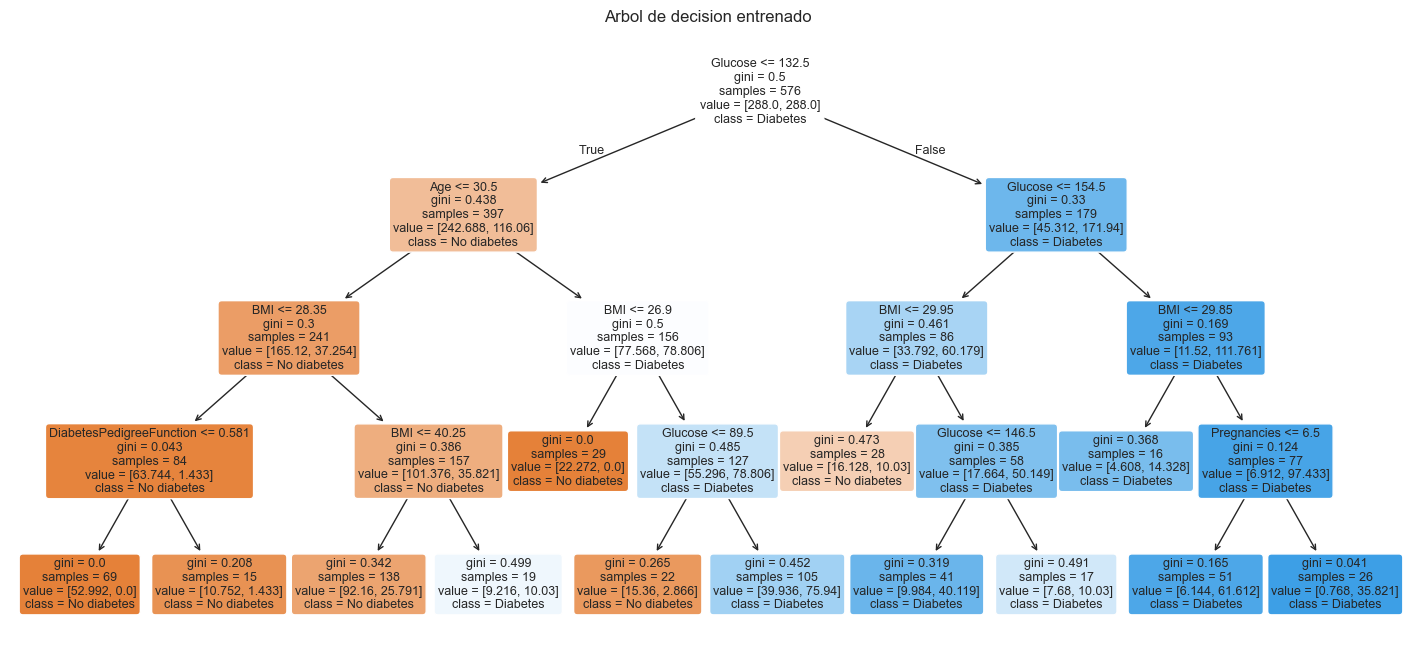

In [25]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model.named_steps["model"],
    feature_names=numeric_features,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Arbol de decision entrenado")
plt.show()

## 10. Analisis de errores

Para entender mejor los errores, identificamos observaciones del conjunto de prueba donde los modelos fallaron. Esto es util para revisar patrones: por ejemplo, pacientes con valores intermedios de glucosa o IMC pueden ser mas dificiles de clasificar.

In [26]:
error_analysis = X_test.copy()
error_analysis["y_real"] = y_test.values
error_analysis["pred_logistica"] = logistic_pred
error_analysis["prob_logistica"] = logistic_proba
error_analysis["pred_arbol"] = tree_pred
error_analysis["prob_arbol"] = tree_proba

logistic_errors = error_analysis[error_analysis["y_real"] != error_analysis["pred_logistica"]]
tree_errors = error_analysis[error_analysis["y_real"] != error_analysis["pred_arbol"]]

print(f"Errores regresion logistica: {len(logistic_errors)}")
print(f"Errores arbol de decision: {len(tree_errors)}")

logistic_errors.head()

Errores regresion logistica: 48
Errores arbol de decision: 52


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,y_real,pred_logistica,prob_logistica,pred_arbol,prob_arbol
698,4,127.0,88.0,11.0,155.0,34.5,0.598,28,0,1,0.584337,0,0.218659
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40,0,1,0.730031,1,0.756659
730,3,130.0,78.0,23.0,79.0,28.4,0.323,34,1,0,0.360378,1,0.655357
335,0,165.0,76.0,43.0,255.0,47.9,0.259,26,0,1,0.899680,1,0.909322
489,8,194.0,80.0,NaN,NaN,26.1,0.551,67,0,1,0.946221,1,0.756659


## 11. Conclusiones

En este notebook construimos un flujo completo de clasificacion binaria para predecir diabetes a partir de variables clinicas.

Aprendizajes principales:

- Un problema es de clasificacion cuando la salida esperada es una categoria.
- La limpieza de datos puede requerir conocimiento del dominio; aqui varios ceros fueron tratados como valores faltantes.
- La division entrenamiento/prueba permite evaluar generalizacion.
- La regresion logistica es una base fuerte, interpretable y apropiada para probabilidades.
- El arbol de decision es interpretable y captura relaciones no lineales, pero puede sobreajustarse si no se regula.
- En problemas medicos, accuracy no basta: precision, recall, F1, matriz de confusion y ROC-AUC dan una mirada mas completa.

Limitaciones:

- El dataset es pequeno y proviene de una poblacion especifica, por lo que no necesariamente generaliza a otras poblaciones.
- Las variables disponibles no capturan todo el contexto clinico.
- El tratamiento de ceros como faltantes es razonable, pero podria mejorarse con criterio medico y validacion externa.
- Los modelos no deben usarse para decisiones clinicas reales sin validacion rigurosa.

Mejoras posibles:

- Usar validacion cruzada para estimar desempeno de forma mas robusta.
- Ajustar hiperparametros con `GridSearchCV` o `RandomizedSearchCV`.
- Probar modelos adicionales como Random Forest, Gradient Boosting o SVM.
- Ajustar el umbral de clasificacion segun el costo relativo de falsos negativos y falsos positivos.
- Evaluar calibracion de probabilidades si el modelo se usara como herramienta de apoyo.